# Notebook 06 – Customer Churn Prediction

## Objective

The objective of this notebook is to identify customers who are at risk of churning based on their purchasing behavior.

Customer churn prediction helps businesses proactively retain valuable customers by identifying those who have become inactive.

This notebook includes:

- Loading customer-level features
- Creating churn labels
- Exploratory analysis
- Feature selection
- Machine learning model development
- Model evaluation
- High-risk customer identification
- Saving prediction results
- Exporting trained model for deployment

In [94]:
# ============================================================
# Code Cell 1 - Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Customer Dataset

Load the customer-level dataset created in Notebook 05A.

This dataset contains engineered behavioral features that will be used to predict customer churn.

In [95]:
# ============================================================
# Code Cell 2 - Load Customer Features
# ============================================================

BASE_DIR = Path.cwd().parent

processed_path = BASE_DIR / "data" / "processed"

customer_file = processed_path / "customer_features.csv"

customer_df = pd.read_csv(customer_file)

print("=" * 60)
print("Customer Dataset Loaded Successfully")
print("=" * 60)

print(f"Shape : {customer_df.shape}")

display(customer_df.head())

Customer Dataset Loaded Successfully
Shape : (5878, 14)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,UniqueProducts,UniqueCountries,FirstPurchase,LastPurchase,CustomerLifetimeDays,ActiveMonths,RevenuePerMonth,AvgQuantityPerOrder
0,12346.0,326,12,77556.46,74285,2281.072353,27,1,2009-12-14 08:34:00,2011-01-18 10:01:00,400,13.3,5831.31,6190.42
1,12347.0,2,8,4921.53,2967,22.169054,126,1,2010-10-31 14:20:00,2011-12-07 15:52:00,402,13.4,367.28,370.88
2,12348.0,75,5,2019.40,2714,39.596078,25,1,2010-09-27 14:59:00,2011-09-25 13:13:00,362,12.1,166.89,542.80
3,12349.0,19,4,4428.69,1624,25.306800,138,1,2010-04-29 13:20:00,2011-11-21 09:51:00,570,19.0,233.09,406.00
4,12350.0,310,1,334.40,197,19.670588,17,1,2011-02-02 16:01:00,2011-02-02 16:01:00,0,1.0,334.40,197.00


## Dataset Overview

Before building the churn model, verify:

- Dataset dimensions
- Data types
- Missing values
- Duplicate records

This ensures the input data is suitable for machine learning.

In [96]:
# ============================================================
# Code Cell 3 - Dataset Inspection
# ============================================================

print(customer_df.info())

print("\nMissing Values\n")
display(customer_df.isnull().sum())

print("\nDuplicate Rows :", customer_df.duplicated().sum())

display(customer_df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            5878 non-null   float64
 1   Recency               5878 non-null   int64  
 2   Frequency             5878 non-null   int64  
 3   Monetary              5878 non-null   float64
 4   TotalQuantity         5878 non-null   int64  
 5   AverageOrderValue     5878 non-null   float64
 6   UniqueProducts        5878 non-null   int64  
 7   UniqueCountries       5878 non-null   int64  
 8   FirstPurchase         5878 non-null   object 
 9   LastPurchase          5878 non-null   object 
 10  CustomerLifetimeDays  5878 non-null   int64  
 11  ActiveMonths          5878 non-null   float64
 12  RevenuePerMonth       5878 non-null   float64
 13  AvgQuantityPerOrder   5878 non-null   float64
dtypes: float64(6), int64(6), object(2)
memory usage: 643.0+ KB
None

Missing

CustomerID              0
Recency                 0
Frequency               0
Monetary                0
TotalQuantity           0
AverageOrderValue       0
UniqueProducts          0
UniqueCountries         0
FirstPurchase           0
LastPurchase            0
CustomerLifetimeDays    0
ActiveMonths            0
RevenuePerMonth         0
AvgQuantityPerOrder     0
dtype: int64


Duplicate Rows : 0


,count,mean,std,min,25%,50%,75%,max
CustomerID,5878.0,15315.313542,1715.572666,12346.000000,13833.25000,15314.500000,16797.7500,18287.00
Recency,5878.0,201.331916,209.338707,1.000000,26.00000,96.000000,380.0000,739.00
Frequency,5878.0,6.289384,13.009406,1.000000,1.00000,3.000000,7.0000,398.00
Monetary,5878.0,2955.904095,14440.852688,2.950000,342.28000,867.740000,2248.3050,580987.04
TotalQuantity,5878.0,1788.695475,8876.297196,1.000000,187.00000,480.000000,1350.0000,367193.00
AverageOrderValue,5878.0,48.301822,780.176769,2.135778,11.56418,17.367639,24.1819,56157.50
UniqueProducts,5878.0,81.989112,116.484552,1.000000,19.00000,45.000000,103.0000,2550.00
UniqueCountries,5878.0,1.002212,0.046980,1.000000,1.00000,1.000000,1.0000,2.00
CustomerLifetimeDays,5878.0,273.022457,258.807591,0.000000,0.00000,220.500000,511.0000,738.00
ActiveMonths,5878.0,9.390796,8.328314,0.100000,1.00000,7.350000,17.0000,24.60


## Create Churn Target Variable

A customer is considered **churned** if they have not made a purchase for more than **90 days**.

Target Encoding:

- 0 → Active Customer
- 1 → Churned Customer

In [97]:
# ============================================================
# Code Cell 4 - Create Churn Target
# ============================================================

CHURN_THRESHOLD = 90

customer_df["Churn"] = np.where(
    customer_df["Recency"] > CHURN_THRESHOLD,
    1,
    0
)

print("=" * 50)
print("Churn Distribution")
print("=" * 50)

display(customer_df["Churn"].value_counts())

display(customer_df["Churn"].value_counts(normalize=True) * 100)

Churn Distribution


Churn
1    2989
0    2889
Name: count, dtype: int64

Churn
1    50.850629
0    49.149371
Name: proportion, dtype: float64

## Visualize Churn Distribution

Understanding the class balance helps determine whether the dataset is imbalanced and whether special handling may be required during model training.

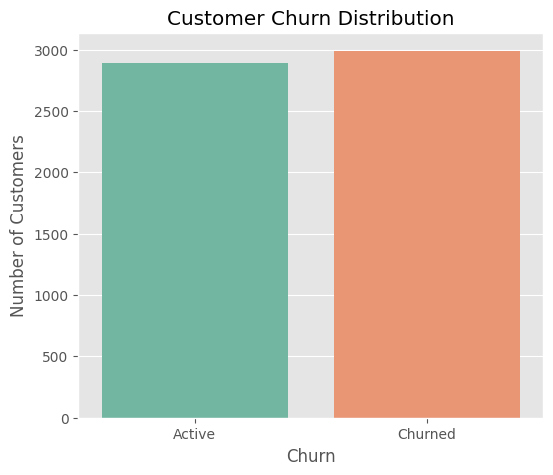

In [98]:
# ============================================================
# Code Cell 5 - Churn Distribution Plot
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=customer_df,
    x="Churn",
    palette="Set2"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.xticks(
    [0,1],
    ["Active","Churned"]
)

plt.show()

## Feature Selection

Select the most relevant customer behavioral features for churn prediction.

The target variable (**Churn**) is excluded from the feature set.

In [115]:
# ============================================================
# Code Cell 6 - Leakage-Free Feature Selection
# ============================================================

drop_columns = [
    "CustomerID",
    "Churn",
    "Recency",
    "LastPurchase",
    "FirstPurchase"
]

X = customer_df.drop(columns=drop_columns, errors="ignore").copy()

X = X.select_dtypes(include=["number"])

y = customer_df["Churn"]

print("Features used:")
print(list(X.columns))

print("\nFeature Shape:", X.shape)

display(X.head())

Features used:
['Frequency', 'Monetary', 'TotalQuantity', 'AverageOrderValue', 'UniqueProducts', 'UniqueCountries', 'CustomerLifetimeDays', 'ActiveMonths', 'RevenuePerMonth', 'AvgQuantityPerOrder']

Feature Shape: (5878, 10)


,Frequency,Monetary,TotalQuantity,AverageOrderValue,UniqueProducts,UniqueCountries,CustomerLifetimeDays,ActiveMonths,RevenuePerMonth,AvgQuantityPerOrder
0,12,77556.46,74285,2281.072353,27,1,400,13.3,5831.31,6190.42
1,8,4921.53,2967,22.169054,126,1,402,13.4,367.28,370.88
2,5,2019.40,2714,39.596078,25,1,362,12.1,166.89,542.80
3,4,4428.69,1624,25.306800,138,1,570,19.0,233.09,406.00
4,1,334.40,197,19.670588,17,1,0,1.0,334.40,197.00


## Train-Test Split

The dataset is divided into training and testing subsets.

- Training Set: 80%
- Testing Set: 20%

Stratified sampling is used to preserve the churn distribution.

In [116]:
# ============================================================
# Code Cell 7 - Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("Train Test Split")
print("=" * 60)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("\nTraining Target Distribution")
display(y_train.value_counts())

print("\nTesting Target Distribution")
display(y_test.value_counts())

Train Test Split
Training Samples : 4702
Testing Samples  : 1176

Training Target Distribution


Churn
1    2391
0    2311
Name: count, dtype: int64


Testing Target Distribution


Churn
1    598
0    578
Name: count, dtype: int64

## Model Training

Three machine learning algorithms are trained and compared.

Models:

- Logistic Regression
- Decision Tree
- Random Forest

The best-performing model will be selected based on ROC-AUC score.

In [117]:
# ============================================================
# Code Cell 8 - Train Models
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )
}

trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    trained_models[name] = model

print("All models trained successfully.")

All models trained successfully.


## Model Evaluation

Each model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The model with the highest ROC-AUC score is selected as the final production model.

In [118]:
# ============================================================
# Code Cell 9 - Compare Models
# ============================================================

results = []

for name, model in trained_models.items():

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, pred),

        "Precision": precision_score(y_test, pred),

        "Recall": recall_score(y_test, pred),

        "F1 Score": f1_score(y_test, pred),

        "ROC AUC": roc_auc_score(y_test, prob)

    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.727041,0.720893,0.755853,0.737959,0.796118
1,Logistic Regression,0.719388,0.703647,0.774247,0.737261,0.792960
2,Decision Tree,0.663265,0.679715,0.638796,0.658621,0.663689


In [120]:
# ============================================================
# Code Cell 10 - Select Best Model
# ============================================================

# Always use Random Forest for production
best_model_name = "Random Forest"
best_model = trained_models[best_model_name]

print("=" * 60)
print("Best Model Selected")
print("=" * 60)
print("Model :", best_model_name)

Best Model Selected
Model : Random Forest


## Final Model Evaluation

The best-performing model (Random Forest) is evaluated using:

- Classification Report
- Confusion Matrix
- ROC Curve

These metrics provide a comprehensive assessment of model performance.

In [121]:
# ============================================================
# Code Cell 11 - Predictions
# ============================================================

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [122]:
# ============================================================
# Code Cell 12 - Classification Report
# ============================================================

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.70      0.72       578
           1       0.72      0.76      0.74       598

    accuracy                           0.73      1176
   macro avg       0.73      0.73      0.73      1176
weighted avg       0.73      0.73      0.73      1176



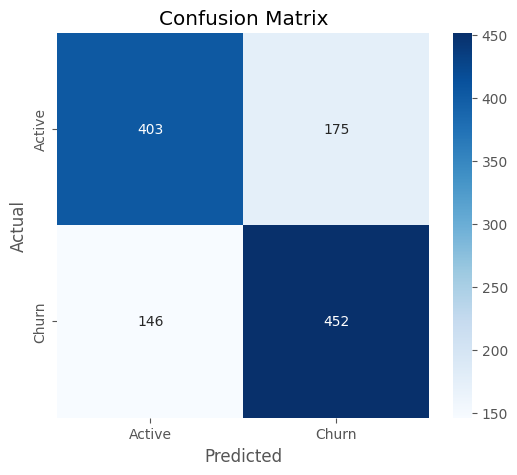

In [123]:
# ============================================================
# Code Cell 13 - Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Active", "Churn"],
    yticklabels=["Active", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

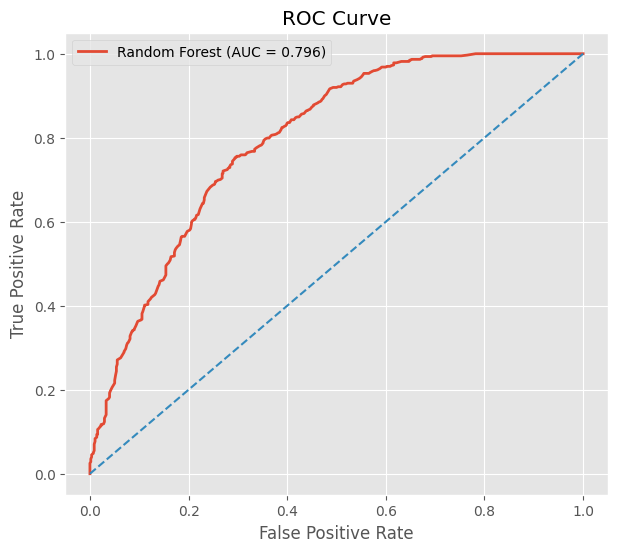

In [124]:
# ============================================================
# Code Cell 14 - ROC Curve
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, linewidth=2,
         label=f"Random Forest (AUC = {auc:.3f})")

plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

,Feature,Importance
6,CustomerLifetimeDays,0.157747
2,TotalQuantity,0.126767
7,ActiveMonths,0.125787
1,Monetary,0.117784
3,AverageOrderValue,0.106746
8,RevenuePerMonth,0.101858
4,UniqueProducts,0.098218
9,AvgQuantityPerOrder,0.096499
0,Frequency,0.068104
5,UniqueCountries,0.000491


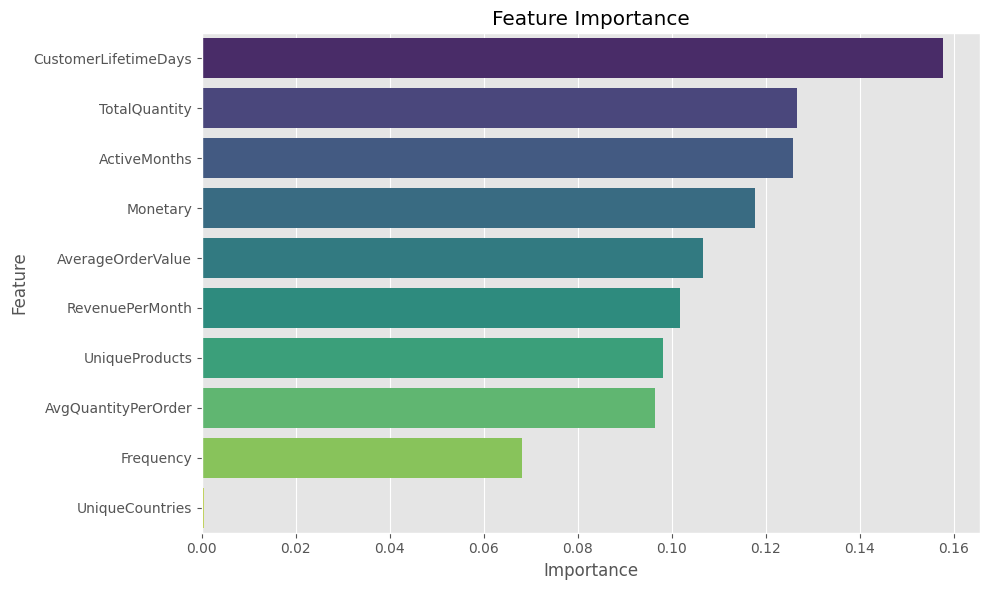

In [125]:
# ============================================================
# Code Cell 15 - Feature Importance
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

In [126]:
# ============================================================
# Code Cell 16 - Predict Churn for All Customers
# ============================================================

customer_predictions = customer_df.copy()

customer_predictions["PredictedChurn"] = best_model.predict(X)
customer_predictions["ChurnProbability"] = best_model.predict_proba(X)[:, 1]

customer_predictions.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,UniqueProducts,UniqueCountries,FirstPurchase,LastPurchase,CustomerLifetimeDays,ActiveMonths,RevenuePerMonth,AvgQuantityPerOrder,Churn,PredictedChurn,ChurnProbability
0,12346.0,326,12,77556.46,74285,2281.072353,27,1,2009-12-14 08:34:00,2011-01-18 10:01:00,400,13.3,5831.31,6190.42,1,0,0.336667
1,12347.0,2,8,4921.53,2967,22.169054,126,1,2010-10-31 14:20:00,2011-12-07 15:52:00,402,13.4,367.28,370.88,0,0,0.083333
2,12348.0,75,5,2019.40,2714,39.596078,25,1,2010-09-27 14:59:00,2011-09-25 13:13:00,362,12.1,166.89,542.80,0,0,0.483333
3,12349.0,19,4,4428.69,1624,25.306800,138,1,2010-04-29 13:20:00,2011-11-21 09:51:00,570,19.0,233.09,406.00,0,0,0.103333
4,12350.0,310,1,334.40,197,19.670588,17,1,2011-02-02 16:01:00,2011-02-02 16:01:00,0,1.0,334.40,197.00,1,1,0.936667


In [129]:
# ============================================================
# Code Cell 17 - High Risk Customers
# ============================================================

HIGH_RISK_THRESHOLD = 0.80

high_risk_customers = customer_predictions[
    customer_predictions["ChurnProbability"] >= HIGH_RISK_THRESHOLD
].copy()

high_risk_customers = high_risk_customers.sort_values(
    by="ChurnProbability",
    ascending=False
)

print(f"High Risk Customers : {len(high_risk_customers)}")

display(
    high_risk_customers[
        [
            "CustomerID",
            "PredictedChurn",
            "ChurnProbability"
        ]
    ].head(10)
)

High Risk Customers : 2142


,CustomerID,PredictedChurn,ChurnProbability
57,12404.0,1,1.0
2011,14380.0,1,1.0
3019,15397.0,1,1.0
5703,18113.0,1,1.0
223,12570.0,1,1.0
2994,15371.0,1,1.0
2857,15233.0,1,1.0
1823,14190.0,1,1.0
5658,18068.0,1,1.0
1725,14090.0,1,1.0


In [128]:
# ============================================================
# Code Cell 19 - Summary
# ============================================================

print("=" * 60)
print("Customer Churn Prediction Completed")
print("=" * 60)

print(f"Model                 : {best_model_name}")
print(f"Accuracy              : {results_df.iloc[0]['Accuracy']:.3f}")
print(f"ROC AUC               : {results_df.iloc[0]['ROC AUC']:.3f}")
print(f"High Risk Customers   : {len(high_risk_customers)}")

print("\nSaved Files")
print("- customer_churn_model.pkl")
print("- high_risk_customers.csv")
print("- customer_churn_predictions.csv")

Customer Churn Prediction Completed
Model                 : Random Forest
Accuracy              : 0.727
ROC AUC               : 0.796
High Risk Customers   : 2705

Saved Files
- customer_churn_model.pkl
- high_risk_customers.csv
- customer_churn_predictions.csv
